#  **Lasso Regression (L1 Regularization)**

1. **Type:** Linear regression with **L1 penalty**.
2. **Penalty term:** Adds the **absolute value** of coefficients to the loss function.
3. **Main purpose:**

   * Reduce overfitting
   * Perform **feature selection**
4. **Key behavior:**

   * L1 penalty can **shrink coefficients to exactly 0**, removing unimportant features.
5. **Good for:**

   * High-dimensional datasets
   * Situations where many features might be irrelevant
6. **Effect:**

   * Produces **sparse models** (only important features kept).
7. **Formula:**

   ```
   Loss = MSE + λ * |coefficients|
   ```
8. **Downside:**

   * When features are highly correlated, Lasso behaves unstable (chooses 1 feature randomly).

---

#  **Ridge vs Lasso — Difference in Simple Points**

### **1. Type of Penalty**

* **Lasso** → L1 (absolute values)
* **Ridge** → L2 (squared values)

---

### **2. Coefficient Shrinkage**

* **Lasso:** Can make some coefficients **exactly 0** → feature selection
* **Ridge:** Shrinks coefficients **but never makes them 0** → no feature selection

---

### **3. Use Cases**

* **Lasso:**

  * Many features
  * Want to find the most important ones
  * Sparse output

* **Ridge:**

  * Features are **highly correlated**
  * Want stable predictions
  * Don’t want to remove features

---

### **4. Model Complexity**

* **Lasso:** Creates simpler, smaller models
* **Ridge:** Keeps all features but reduces impact

---

### **5. Geometric Difference (Easy Version)**

* **Lasso constraint** → diamond shape → promotes 0 coefficients
* **Ridge constraint** → circle shape → coefficients shrink smoothly

---

### **6. Overfitting Handling**

* Both reduce overfitting
* **Ridge** is usually better when all features contribute a little
* **Lasso** is better when only few features matter

---

### **7. Stability with Correlated Features**

* **Lasso:** Unstable (will pick one and drop others)
* **Ridge:** Stable (shares weight among correlated features)

---

#  Short Summary (1 line each)

* **Lasso = L1 = makes some coefficients zero = feature selection.**
* **Ridge = L2 = shrinks coefficients but keeps all = no feature selection.**

---

# code

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[27.06393783]
-2.9333246504972195


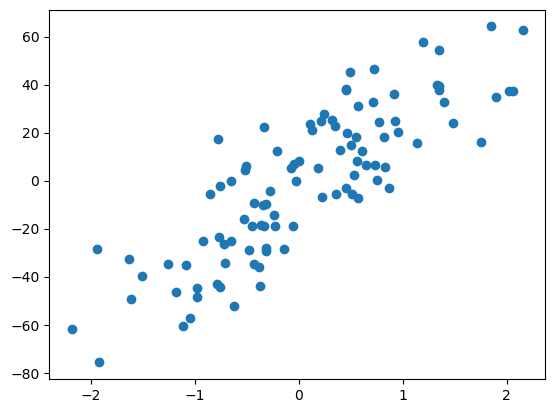

In [3]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

f:\anaconda3\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
f:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
f:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.098e+04, tolerance: 7.838e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


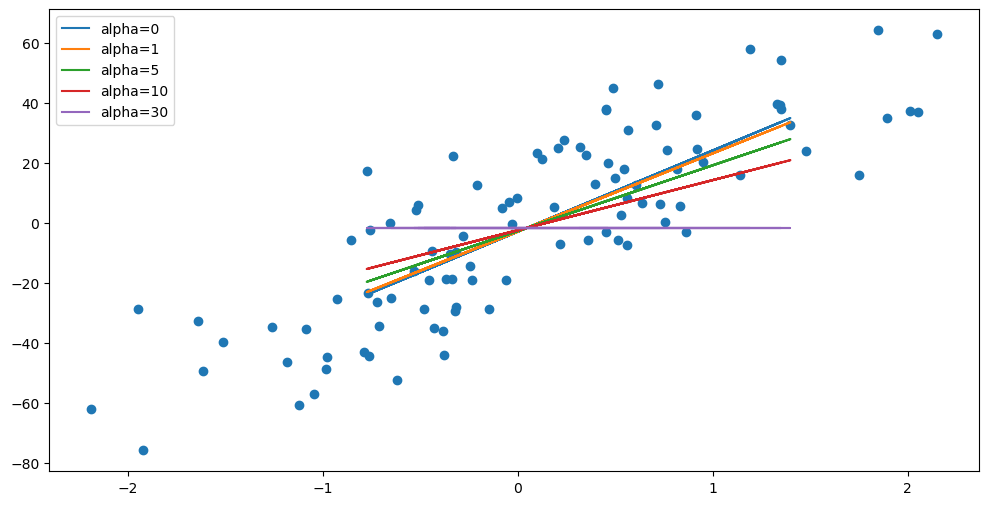

In [4]:
alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i))
plt.legend()
plt.show()

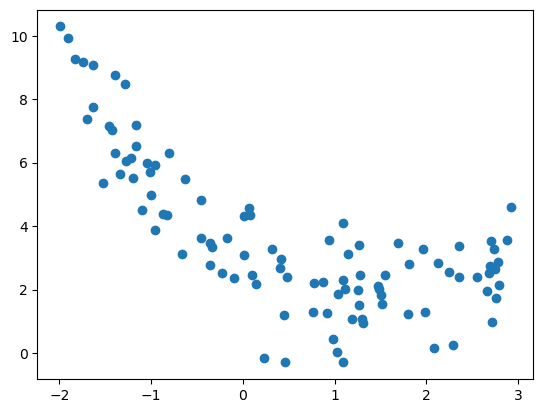

In [5]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

f:\anaconda3\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
f:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
f:\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.152e+01, tolerance: 5.762e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
f:\anaconda3\Lib\site-pac

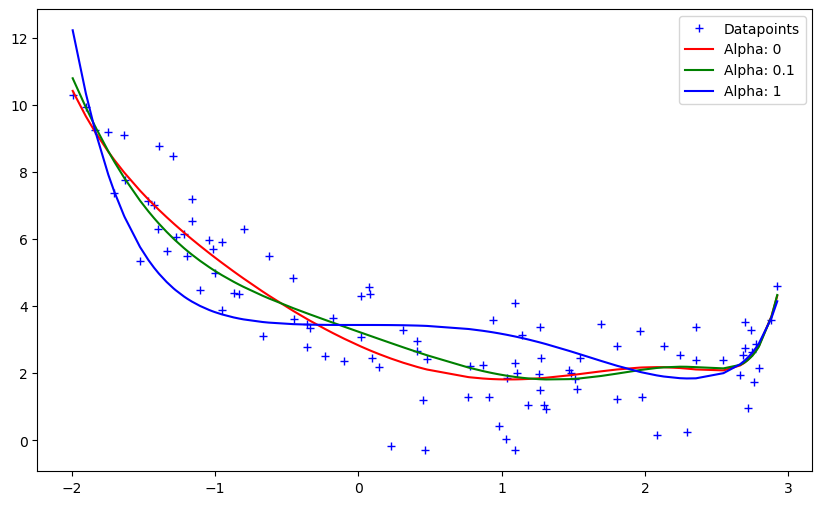

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()